In [1]:
from pyAndorSDK2 import atmcd

In [3]:
import pyAndorSDK2
print(pyAndorSDK2.__file__)


C:\Users\raithel-lab\AppData\Roaming\Python\Python312\site-packages\pyAndorSDK2\__init__.py


In [32]:
sdk = atmcd()
sdk.Initialize("")

(20002, 512, 512)

In [33]:
sdk.GetDetector()[1:]

(512, 512)

In [45]:
sdk.SetTemperature(-50)

20002

In [46]:
sdk.GetTemperatureF()[1]

-51.34000015258789

In [42]:
bool(sdk.IsCoolerOn()[1])

True

In [39]:
sdk.CoolerON()

20002

In [179]:
from matplotlib import pyplot as plt

In [18]:
from pyAndorSDK2 import atmcd

class Andor:
    """
    There are several internal parameters stored in the instance. This can save a lot when calling these current state instead of using get method.
    These parameters are stored during the set function and acquired through get method to ensure the accuracy.
    """
    def __init__(self, temperature):

        self.sdk = atmcd("")
        ret = self.sdk.Initialize("")
        self.set_temperature(temperature)
        
        self.width                = self.sdk.GetDetector()[1]
        self.height               = self.sdk.GetDetector()[2]
        self.setting_tem_point    = None
        self.EMGain               = None
        self.EMGain_range         = self.get_EMGain_range()
        # self.preampgain      = None
        # self.channel         = None
        # self.outamp          = None
        # self.hsspeed         = None
        # self.vsspeed         = None
        # self.serial          = None
        self.exposure             = None
        # self.accumulate      = None
        # self.kinetic         = None
        self.read_mode            = None
        self.acquisition_mode     = None
        # self.scans           = 1
        self.hbin                 = 1
        self.vbin                 = 1
        self.hstart      = 1
        self.hend        = self.width
        self.vstart      = 1
        self.vend        = self.height
        self.if_set_the_region = False
        self.cooler      = None
        self.fan_mode = None


    def shutdown(self):
        result = self.sdk.ShutDown()
        if result == 20002:
            print("camera is successfully shutdown")

    def stop(self):
        result = self.sdk.AbortAcquisition()
        if result == 20002:
            print("the acquisition is successfully aborted")
            
    # def get_all_setups(self):
    #     print("Cooler: " + self.get_cooler_status())
    #     print("Current teperature: " + self.get_temperature() + self.get_temperature_status())
    #     print("")
    
    ### Temperature control
    def set_fan_mode(self, mode):
        dic = {"full":0,"low":0,"off":2}
        """
        0: full
        1: low
        2: off
        """
        self.sdk.SetFanMode(dic[mode])
        self.fan_mode = mode
    
    def set_cooler(self, on=True):
        """Set the cooler on or off"""
        if on:
            self.sdk.CoolerON()
            self.cooler = True
        else:
            self.sdk.CoolerOFF()
            self.cooler = False
        return self.get_cooler_status()

    def get_cooler_status(self):
        """Check if the cooler is on"""
        return bool(self.sdk.IsCoolerOn())

    def get_temperature_status(self):
        """
        Get temperature status.
        """
        state = self.sdk.GetTemperatureF()[0]
        
        return ERROR_CODE[state]

    def get_temperature(self):
        """Get the current camera temperature (in C)"""
        return self.sdk.GetTemperatureF()[1]
        
    def set_temperature(self, temperature, enable_cooler=True):
        """
        Change the temperature setpoint (in C).

        If ``enable_cooler==True``, turn the cooler on automatically if present.
        """
        self.sdk.SetTemperature(temperature)
        self.setting_tem_point = temperature
        if enable_cooler:
            self.set_cooler(True)
        return temperature

    def get_temperature_range(self):
        """Return the available range of temperatures (in C)"""
        return self.sdk.GetTemperatureRange()[1:]
    
    
    ### Gain control
    def set_EMGain(self, Gain):
        """
        when EMGain = 0, means the gain is off
        """
        if self.EMGain_range[0]-1 <= Gain <= self.EMGain_range[1]:
            self.sdk.SetEMCCDGain(Gain)
            self.EMGain = self.get_EMGain() # use get function to avoid truncate error by the equipment
        else:
            print("Gain is out of range")
        
    def get_EMGain(self):
        return self.sdk.GetEMCCDGain()[1]

    def get_EMGain_range(self):
        """
        1 - a number
        """
        return self.sdk.GetEMGainRange()[1:]

    # def set_pre_gain(self, gain):
    #     range_lower = 0
    #     range
    # #     error = self.dll.SetPreAmpGain(index)
    # #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    # #     self.preampgain = index
    # #     return ERROR_CODE[error]

    # def get_pre_gain(self):
    #     self.preAmpGain = []

    #     for i in range(self.noGains):
    #         self.dll.GetPreAmpGain(i,byref(gain))
    #         self.preAmpGain.append(gain.value)

    ### Acquisition parameters
    def set_exposure_time(self, time):
        self.sdk.SetExposureTime(time)
        self.exposure = self.get_exposure_time()

    def get_exposure_time(self):
        """Get current exposure"""
        return self.sdk.GetAcquisitionTimings()[1]

    # def GetAcquisitionTimings(self):
    #     exposure   = c_float()
    #     accumulate = c_float()
    #     kinetic    = c_float()
    #     error = self.dll.GetAcquisitionTimings(byref(exposure),byref(accumulate),byref(kinetic))
    #     self.exposure = exposure.value
    #     self.accumulate = accumulate.value
    #     self.kinetic = kinetic.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def get_min_shutter_times(self):
    #     """Get minimal shutter opening and closing times"""
    #     return self.sdk.GetShutterMinTimes()

    def set_shutter(self, mode, ttl_mode=1, open_time = 0, close_time = 0):
        """
        mode:
        0:Fully Auto 
        1: Permanently Open 
        2: Permanently Closed 
        4: Open for FVB series
        5: Open for any series

        ttl_mode:
        0: Output TTL low signal to open shutter
        1: Output TTL high signal to open shutter

        close_time: Time shutter takes to close (milliseconds) 
        open_time: Time shutter takes to open (milliseconds) 
        """
        self.sdk.SetShutter(ttl_mode,mode,close_time,open_time)

    
    ### Acqusition mode
    def set_trigger_mode(self, mode):
        """
        0  Internal  
        1  External
        6  External Start
        7  External Exposure (Bulb)
        9  External FVB EM (only valid for EM Newton models in FVB mode)
        10 Software Trigger
        12 External Charge Shifting
        """
        self.sdk.SetTriggerMode(mode)
    
    def start_acquisition(self):
        self.sdk.PrepareAcquisition()
        self.sdk.StartAcquisition()
        self.sdk.WaitForAcquisition()

    def set_acquisition_region(self,hbin,vbin,hstart,hend,vstart,vend):
        """
        set the readout region. In this mode, the ROI is set based on software, the unwanted data is discarded
        """
        self.sdk.SetImage(hbin,vbin,hstart,hend,vstart,vend)
        self.hbin = hbin
        self.vbin = vbin
        self.hstart = hstart
        self.hend = hend
        self.vstart = vstart
        self.vend = vend
        self.if_set_the_region = True

    def set_acquisition_region_high_speed(self,hbin,vbin,hend,vend):
        """
        the crop mode can only handle the corner region. The ROI is set hardwarely
        """
        self.sdk.SetIsolatedCropMode(1,vend,hend,vbin,hbin)
        self.hbin = hbin
        self.vbin = vbin
        self.hend = hend
        self.vend = vend
        self.if_set_the_region = True
    
    def set_single_acquisition(self,exposure_time, EMGain = 0, trigger_mode = 0, read_mode = 4):
        if self.if_set_the_region:
            self.sdk.SetAcquisitionMode(1)
            self.acquisition_mode = 1
            self.set_trigger_mode(trigger_mode)
            self.set_read_mode(read_mode)
            self.set_exposure_time(exposure_time)
            self.set_EMGain(EMGain)
        else:
            raise RuntimeError("Please set up the acquisition region by set_acquisition_region()")

    ### Read acquisition result
    def set_read_mode(self, mode):
        """
        0: Full vertical binning
        1: multi track
        2: random track
        3: single track
        4: image
        """
        self.sdk.SetReadMode(mode)
        self.read_mode = mode

    def get_acquired_data(self):
        if (self.read_mode == 4):
            if (self.acquisition_mode == 1):
                dim = self.width * self.height / self.hbin / self.vbin
            elif (self.acquisition_mode==3):
                dim = self.width * self.height / self.hbin / self.vbin * self.scans
        elif (self.ReadMode==3 or self.ReadMode==0):
            if (self.AcquisitionMode==1):
                dim = self.width
            elif (self.AcquisitionMode==3):
                dim = self.width * self.scans

        ret,arr,validfirst,validlast = self.sdk.GetImages(1, 1, int(dim))

        return arr
   

   
    
    # def __del__(self):
    #     error = self.dll.ShutDown()
        

    # # def verbose(self, error, function=''):
    # #     if self.verbosity is True:
    # #         print("[%s]: %s" %(function, error))

    # def SetVerbose(self, state=True):
    #     self.verbose = state

    # def AbortAcquisition(self):
    #     error = self.dll.AbortAcquisition()
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]


        
        
    # def GetCameraSerialNumber(self):
    #     serial = c_int()
    #     error = self.dll.GetCameraSerialNumber(byref(serial))
    #     self.serial = serial.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]



    # def SetAcquisitionMode(self, mode):
    #     #1: Single scan
    #     #3: Kinetic scan
    #     error = self.dll.SetAcquisitionMode(mode)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.AcquisitionMode = mode
    #     return ERROR_CODE[error]
        
    # def SetNumberKinetics(self,numKin):
    #     error = self.dll.SetNumberKinetics(numKin)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.scans = numKin
    #     return ERROR_CODE[error]

    # def SetNumberAccumulations(self,number):
    #     error = self.dll.SetNumberAccumulations(number)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def SetAccumulationCycleTime(self,time):
    #     error = self.dll.SetAccumulationCycleTime(c_float(time))
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def SetKineticCycleTime(self,time):
    #     error = self.dll.SetKineticCycleTime(c_float(time))
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]



    # def SetImage(self,hbin,vbin,hstart,hend,vstart,vend):
    #     self.hbin = hbin
    #     self.vbin = vbin
    #     self.hstart = hstart
    #     self.hend = hend
    #     self.vstart = vstart
    #     self.vend = vend
        
    #     error = self.dll.SetImage(hbin,vbin,hstart,hend,vstart,vend)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]






        


    # def SetSingleScan(self):
    #     self.SetReadMode(4)
    #     self.SetAcquisitionMode(1)
    #     self.SetImage(1,1,1,self.width,1,self.height)

        


    # def SaveAsBmp(self, path):
    #     im=Image.new("RGB",(self.width,self.height),"white")
    #     pix = im.load()

    #     for i in range(len(self.imageArray)):
    #         (row, col) = divmod(i,self.width)
    #         picvalue = int(round(self.imageArray[i]*255.0/65535))
    #         pix[col,row] = (picvalue,picvalue,picvalue)

    #     im.save(path,"BMP")

    # def SaveAsTxt(self, path):
    #     file = open(path, 'w')

    #     for line in self.imageArray:
    #         file.write("%g\n" % line)

    #     file.close()

    # def SetImageRotate(self, iRotate):
    #     error = self.dll.SetImageRotate(iRotate)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)

    # def SaveAsBmpNormalised(self, path):

    #     im=Image.new("RGB",(self.width,self.height),"white")
    #     pix = im.load()

    #     maxIntensity = max(self.imageArray)

    #     for i in range(len(self.imageArray)):
    #         (row, col) = divmod(i,self.width)
    #         picvalue = int(round(self.imageArray[i]*255.0/maxIntensity))
    #         pix[col,row] = (picvalue,picvalue,picvalue)

    #     im.save(path,"BMP")
        
    # def SaveAsFITS(self, filename, type):
    #     error = self.dll.SaveAsFITS(filename, type)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]




     
    # def SetEMCCDGainMode(self, gainMode):
    #     error = self.dll.SetEMCCDGainMode(gainMode)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]   
        

        
    # def SetEMAdvanced(self, gainAdvanced):
    #     error = self.dll.SetEMAdvanced(gainAdvanced)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]


      
    # def GetNumberADChannels(self):
    #     noADChannels = c_int()
    #     error = self.dll.GetNumberADChannels(byref(noADChannels))
    #     self.noADChannels = noADChannels.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def GetBitDepth(self):
    #     bitDepth = c_int()

    #     self.bitDepths = []

    #     for i in range(self.noADChannels):
    #         self.dll.GetBitDepth(i,byref(bitDepth))
    #         self.bitDepths.append(bitDepth.value)

    # def SetADChannel(self, index):
    #     error = self.dll.SetADChannel(index)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.channel = index
    #     return ERROR_CODE[error]  
        
    # def SetOutputAmplifier(self, index):
    #     error = self.dll.SetOutputAmplifier(index)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.outamp = index
    #     return ERROR_CODE[error]
        
    # def GetNumberHSSpeeds(self):
    #     noHSSpeeds = c_int()
    #     error = self.dll.GetNumberHSSpeeds(self.channel, self.outamp, byref(noHSSpeeds))
    #     self.noHSSpeeds = noHSSpeeds.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def GetHSSpeed(self):
    #     HSSpeed = c_float()

    #     self.HSSpeeds = []

    #     for i in range(self.noHSSpeeds):
    #         self.dll.GetHSSpeed(self.channel, self.outamp, i, byref(HSSpeed))
    #         self.HSSpeeds.append(HSSpeed.value)
            
    # def SetHSSpeed(self, itype, index):
    #     error = self.dll.SetHSSpeed(itype,index)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.hsspeed = index
    #     return ERROR_CODE[error]
        
    # def GetNumberVSSpeeds(self):
    #     noVSSpeeds = c_int()
    #     error = self.dll.GetNumberVSSpeeds(byref(noVSSpeeds))
    #     self.noVSSpeeds = noVSSpeeds.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def GetVSSpeed(self):
    #     VSSpeed = c_float()

    #     self.VSSpeeds = []

    #     for i in range(self.noVSSpeeds):
    #         self.dll.GetVSSpeed(i,byref(VSSpeed))
    #         self.preVSpeeds.append(VSSpeed.value)

    # def SetVSSpeed(self, index):
    #     error = self.dll.SetVSSpeed(index)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     self.vsspeed = index
    #     return ERROR_CODE[error] 
    
    # def GetNumberPreAmpGains(self):
    #     noGains = c_int()
    #     error = self.dll.GetNumberPreAmpGains(byref(noGains))
    #     self.noGains = noGains.value
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]



    # def SetTriggerMode(self, mode):
    #     error = self.dll.SetTriggerMode(mode)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def GetStatus(self):
    #     status = c_int()
    #     error = self.dll.GetStatus(byref(status))
    #     self.status = ERROR_CODE[status.value]
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return self.status
        
    # def GetSeriesProgress(self):
    #     acc = c_long()
    #     series = c_long()
    #     error = self.dll.GetAcquisitionProgress(byref(acc),byref(series))
    #     if ERROR_CODE[error] == "DRV_SUCCESS":
    #         return series.value
    #     else:
    #         return None
             
    # def GetAccumulationProgress(self):
    #     acc = c_long()
    #     series = c_long()
    #     error = self.dll.GetAcquisitionProgress(byref(acc),byref(series))
    #     if ERROR_CODE[error] == "DRV_SUCCESS":
    #         return acc.value
    #     else:
    #         return None
        
    # def SetFrameTransferMode(self, frameTransfer):
    #     error = self.dll.SetFrameTransferMode(frameTransfer)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]
        
    # def SetShutterEx(self, typ, mode, closingtime, openingtime, extmode):
    #     error = self.dll.SetShutterEx(typ, mode, closingtime, openingtime, extmode)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]
        
    # def SetSpool(self, active, method, path, framebuffersize):
    #     error = self.dll.SetSpool(active, method, c_char_p(path), framebuffersize)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]

    # def SetSingleTrack(self, centre, height):
    #     error = self.dll.SetSingleTrack(centre, height)
    #     self.verbose(ERROR_CODE[error], sys._getframe().f_code.co_name)
    #     return ERROR_CODE[error]
    
    # def SetDemoReady(self):
    #     error = self.SetSingleScan()
    #     error = self.SetTriggerMode(0)
    #     error = self.SetShutter(1,0,30,30)
    #     error = self.SetExposureTime(0.01)
    #     return error
    

ERROR_CODE = {
    20001: "DRV_ERROR_CODES",
    20002: "DRV_SUCCESS",
    20003: "DRV_VXNOTINSTALLED",
    20006: "DRV_ERROR_FILELOAD",
    20007: "DRV_ERROR_VXD_INIT",
    20010: "DRV_ERROR_PAGELOCK",
    20011: "DRV_ERROR_PAGE_UNLOCK",
    20013: "DRV_ERROR_ACK",
    20024: "DRV_NO_NEW_DATA",
    20026: "DRV_SPOOLERROR",
    20034: "DRV_TEMP_OFF",
    20035: "DRV_TEMP_NOT_STABILIZED",
    20036: "DRV_TEMP_STABILIZED",
    20037: "DRV_TEMP_NOT_REACHED",
    20038: "DRV_TEMP_OUT_RANGE",
    20039: "DRV_TEMP_NOT_SUPPORTED",
    20040: "DRV_TEMP_DRIFT",
    20050: "DRV_COF_NOTLOADED",
    20053: "DRV_FLEXERROR",
    20066: "DRV_P1INVALID",
    20067: "DRV_P2INVALID",
    20068: "DRV_P3INVALID",
    20069: "DRV_P4INVALID",
    20070: "DRV_INIERROR",
    20071: "DRV_COERROR",
    20072: "DRV_ACQUIRING",
    20073: "DRV_IDLE",
    20074: "DRV_TEMPCYCLE",
    20075: "DRV_NOT_INITIALIZED",
    20076: "DRV_P5INVALID",
    20077: "DRV_P6INVALID",
    20083: "P7_INVALID",
    20089: "DRV_USBERROR",
    20091: "DRV_NOT_SUPPORTED",
    20095: "DRV_INVALID_TRIGGER_MODE",
    20099: "DRV_BINNING_ERROR",
    20990: "DRV_NOCAMERA",
    20991: "DRV_NOT_SUPPORTED",
    20992: "DRV_NOT_AVAILABLE"
}

In [2]:
cam = Andor(-50)

NameError: name 'Andor' is not defined

In [1]:
cam.get_temperature()

NameError: name 'cam' is not defined

In [8]:
cam.get_temperature_status()

'DRV_TEMP_NOT_STABILIZED'

In [97]:
cam.get_cooler_status()

True

In [98]:
cam.set_temperature(-50)

-50

In [99]:
cam.get_temperature_range()

(-100, 20)

In [100]:
cam.get_EMGain()

10

In [101]:
cam.get_EMGain_range()

(1, 255)

In [102]:
cam.set_EMGain(10)
cam.EMGain

10

In [103]:
cam.set_exposure_time(0.001)

In [118]:
# cam.get_exposure_time()
cam.exposure

In [28]:
sdk.GetShutterMinTimes()

(20002, 0, 0)

In [7]:
cam.set_shutter(mode = 0)

In [500]:
sdk.ShutDown()

20002

In [108]:
cam.start_acquisition

<bound method Andor.start_acquisition of <__main__.Andor object at 0x0000017DFE08CB60>>

In [109]:
cam.set_read_mode(4)

In [110]:
cam.read_mode

4

In [111]:
cam.acquisition_mode

In [135]:
cam.EMGain_range

(1, 255)

In [138]:
cam.set_single_acquisition(exposure_time=0.01)


In [8]:
cam.set_single_acquisition(exposure_time=0.001)

In [ ]:
cam.start_acquisition()
sdk.WaitForAcquisition()

In [4]:
sdk = atmcd("")  # Load the atmcd library

In [206]:
cam.read_mode

4

In [207]:
cam.acquisition_mode

1

In [34]:
arr=cam.get_acquired_data()

In [35]:
arr

array([ 998,  995,  988, ..., 1345, 1351, 1348])

In [5]:
cam.set_single_acquisition(exposure_time=0.001)


In [6]:
cam.sdk.SetImage(1, 1, 1, cam.width, 1, cam.height)


20002

In [7]:
cam.sdk.PrepareAcquisition()


20002

In [8]:
cam.start_acquisition()


In [9]:

(ret, arr, validfirst, validlast) = cam.sdk.GetImages16(1, 1, cam.width*cam.height)

In [10]:
arr

array([1003, 1004,  989, ...,  987,  990,  995], dtype=int16)

In [ ]:
cam.start_acquisition()
sdk.WaitForAcquisition()

In [33]:
cam.acquisition_mode

1

In [32]:
# Set full-frame imaging
cam.sdk.SetImage(1, 1, 1, cam.width, 1, cam.height)

# Configure single scan
cam.set_single_acquisition(0.001,1)    # 1 = Single Scan
cam.set_read_mode(4)              # 4 = Image mode
cam.sdk.SetTriggerMode(0)         # 0 = Internal trigger (start immediately)
cam.set_exposure_time(0.001)      # 1 ms exposure

# Open shutter (mode=1 = permanently open)
cam.set_shutter(mode=1)

# Start acquisition and wait for completion
cam.start_acquisition()
# cam.sdk.WaitForAcquisition()

In [24]:
(ret, arr, validfirst, validlast) = cam.sdk.GetImages16(1, 1, cam.width*cam.height)

In [25]:
arr

array([ 990, 1000,  995, ..., 1003, 1002, 1008], dtype=int16)

In [ ]:
from enum import IntEnum, unique


@unique
class Read_Mode(IntEnum):
    """Read mode options
    """
    FULL_VERTICAL_BINNING = 0
    MULTI_TRACK = 1
    RANDOM_TRACK = 2
    SINGLE_TRACK = 3
    IMAGE = 4


@unique
class Trigger_Mode(IntEnum):
    """Trigger mode options
    """
    INTERNAL = 0
    EXTERNAL = 1
    EXTERNAL_START = 6
    EXTERNAL_EXPOSURE_BULB = 7
    EXTERNAL_FVB_EM = 9
    SOFTWARE_TRIGGER = 10
    EXTERNAL_CHARGE_SHIFTING = 12


@unique
class Acquisition_Mode(IntEnum):
    """Acquistion mode options
    """
    SINGLE_SCAN = 1
    ACCUMULATE = 2
    KINETICS = 3
    FAST_KINETICS = 4
    RUN_TILL_ABORT = 5


@unique
class Spool_Mode(IntEnum):
    """Spool mode options
    """
    FILE_32_BIT_SEQUENCE = 0
    # Format of data in files depends on whether multiple accumulations are being taken for each scan. Format will be 32-bit integer if data is being accumulated each scan; otherwise the format will be 16-bit integer.
    DATA_DEPENDENT_FORMAT = 1
    FILE_16_BIT_SEQUENCE = 2
    MULTIPLE_DIRECTORY_STRUCTURE = 3
    SPOOL_TO_RAM = 4
    SPOOL_TO_16_BIT_FITS = 5
    SPOOL_TO_SIF = 6
    SPOOL_TO_16_BIT_TIFF = 7
    COMPRESSED_MULTIPLE_DIRECTORY_STRUCTURE = 8


@unique
class Gate_Mode(IntEnum):
    """Gate mode options
    """
    FIRE_ANDED_WITH_THE_GATE_INPUT = 0
    GATING_CONTROLLED_FROM_FIRE_PULSE_ONLY = 1
    GATING_CONTROLLED_FROM_SMB_GATE_INPUT_ONLY = 2
    GATING_ON_CONTINUOUSLY = 3
    GATING_OFF_CONTINUOUSLY = 4
    GATE_USING_DDG = 5


@unique
class Shutter_Mode(IntEnum):
    """Shutter mode options
    """
    FULLY_AUTO = 0
    PERMANENTLY_OPEN = 1
    PERMANENTLY_CLOSED = 2
    OPEN_FOR_FVB_SERIES = 4
    OPEN_FOR_ANY_SERIES = 5


In [4]:
import numpy as np

In [6]:
1<=2<=3

True

Function Initialize returned 20002
Function GetCameraSerialNumber returned 20002 Serial No: 1374
Function CoolerON returned 20002
Function SetAcquisitionMode returned 20002 mode = Single Scan
Function SetReadMode returned 20002 mode = FVB
Function SetTriggerMode returned 20002 mode = Internal
Function GetDetector returned 20002 xpixels = 512 ypixels = 512
Function SetExposureTime returned 20002 time = 0.01s
Function GetAcquisitionTimings returned 20002 exposure = 0.01 accumulate = 0.04219 kinetic = 0.04219
Function PrepareAcquisition returned 20002
Function StartAcquisition returned 20002
Function WaitForAcquisition returned 20002
Function GetImages16 returned 20069 first pixel = 0 size = 262144
Function ShutDown returned 20002


In [19]:
arr

array([0, 0, 0, ..., 0, 0, 0], dtype=int16)

In [20]:
from pyAndorSDK2 import atmcd, atmcd_codes, atmcd_errors

sdk = atmcd("")  # Load the atmcd library
codes = atmcd_codes
ret = sdk.Initialize("")  # Initialize camera
print("Function Initialize returned {}".format(ret))

if atmcd_errors.Error_Codes.DRV_SUCCESS == ret:

    (ret, iSerialNumber) = sdk.GetCameraSerialNumber()
    print("Function GetCameraSerialNumber returned {} Serial No: {}".format(
        ret, iSerialNumber))
    # Configure the acquisition
    ret = sdk.CoolerON()
    print("Function CoolerON returned {}".format(ret))

    ret = sdk.SetAcquisitionMode(codes.Acquisition_Mode.SINGLE_SCAN)
    print("Function SetAcquisitionMode returned {} mode = Single Scan".format(ret))

    ret = sdk.SetReadMode(codes.Read_Mode.IMAGE)
    print("Function SetReadMode returned {} mode = Image".format(ret))

    ret = sdk.SetTriggerMode(codes.Trigger_Mode.INTERNAL)
    print("Function SetTriggerMode returned {} mode = Internal".format(ret))

    (ret, xpixels, ypixels) = sdk.GetDetector()
    print("Function GetDetector returned {} xpixels = {} ypixels = {}".format(
        ret, xpixels, ypixels))

    ret = sdk.SetImage(1, 1, 1, xpixels, 1, ypixels)
    print("Function SetImage returned {} hbin = 1 vbin = 1 hstart = 1 hend = {} vstart = 1 vend = {}".format(
        ret, xpixels, ypixels))

    ret = sdk.SetExposureTime(0.01)
    print("Function SetExposureTime returned {} time = 0.01s".format(ret))

    (ret, fminExposure, fAccumulate, fKinetic) = sdk.GetAcquisitionTimings()
    print("Function GetAcquisitionTimings returned {} exposure = {} accumulate = {} kinetic = {}".format(
        ret, fminExposure, fAccumulate, fKinetic))

    ret = sdk.PrepareAcquisition()
    print("Function PrepareAcquisition returned {}".format(ret))

    # Perform Acquisition
    ret = sdk.StartAcquisition()
    print("Function StartAcquisition returned {}".format(ret))

    ret = sdk.WaitForAcquisition()
    print("Function WaitForAcquisition returned {}".format(ret))

    imageSize = xpixels * ypixels
    (ret, arr, validfirst, validlast) = sdk.GetImages16(1, 1, imageSize)
    print("Function GetImages16 returned {} first pixel = {} size = {}".format(
        ret, arr[0], imageSize))

    # Clean up
    ret = sdk.ShutDown()
    print("Function ShutDown returned {}".format(ret))

else:
    print("Cannot continue, could not initialise camera {}".format(ret))


Function Initialize returned 20002
Function GetCameraSerialNumber returned 20002 Serial No: 1374
Function CoolerON returned 20002
Function SetAcquisitionMode returned 20002 mode = Single Scan
Function SetReadMode returned 20002 mode = Image
Function SetTriggerMode returned 20002 mode = Internal
Function GetDetector returned 20002 xpixels = 512 ypixels = 512
Function SetImage returned 20002 hbin = 1 vbin = 1 hstart = 1 hend = 512 vstart = 1 vend = 512
Function SetExposureTime returned 20002 time = 0.01s
Function GetAcquisitionTimings returned 20002 exposure = 0.01 accumulate = 0.04219 kinetic = 0.04219
Function PrepareAcquisition returned 20002
Function StartAcquisition returned 20002
Function WaitForAcquisition returned 20002
Function GetImages16 returned 20002 first pixel = 1000 size = 262144
Function ShutDown returned 20002


In [21]:
arr

array([1000, 1000, 1000, ..., 1001, 1003,  997], dtype=int16)

In [51]:
# wrap up

from pyAndorSDK2 import atmcd, atmcd_codes, atmcd_errors

sdk = atmcd("")  # Load the atmcd library
codes = atmcd_codes
ret = sdk.Initialize("")  # Initialize camera
print("Function Initialize returned {}".format(ret))






Function Initialize returned 20002


In [52]:
sdk.SetTemperature(-60)

20002

In [53]:
sdk.CoolerON()

20002

In [54]:
sdk.GetTemperatureF()

(20037, -54.584999084472656)

In [55]:
def single_image(exposure_time,EMGain):
       
    sdk.SetAcquisitionMode(codes.Acquisition_Mode.SINGLE_SCAN)
    sdk.SetReadMode(codes.Read_Mode.IMAGE)
    sdk.SetTriggerMode(codes.Trigger_Mode.INTERNAL)
    (ret, xpixels, ypixels) = sdk.GetDetector()
    sdk.SetImage(1, 1, 1, xpixels, 1, ypixels)
    sdk.SetExposureTime(exposure_time)
    sdk.SetEMCCDGain(EMGain)
    # sdk.SetShutter(0)
    sdk.PrepareAcquisition()
    sdk.StartAcquisition()
    sdk.WaitForAcquisition()
    imageSize = xpixels * ypixels
    (ret, arr, validfirst, validlast) = sdk.GetImages16(1, 1, imageSize)
    return arr.reshape(xpixels,ypixels)

In [56]:
sdk.SetShutter(1,1,0,0)
# arr = single_image(0.001,20)

20002

In [55]:
arr

array([[ 987, 1005,  978, ..., 1001,  994,  995],
       [1006,  996,  983, ..., 1003,  988, 1015],
       [1013,  993,  998, ..., 1004,  984, 1000],
       ...,
       [1182, 1167, 1147, ..., 1167, 1152, 1160],
       [1162, 1166, 1154, ..., 1154, 1175, 1183],
       [1185, 1163, 1154, ..., 1182, 1164, 1178]], dtype=int16)

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [59]:
sdk.ShutDown()

20002

In [ ]:
10 50 100 150 175 190 200 210 220 230 240 255

In [413]:
EMGain_list = []
Actual_list = []

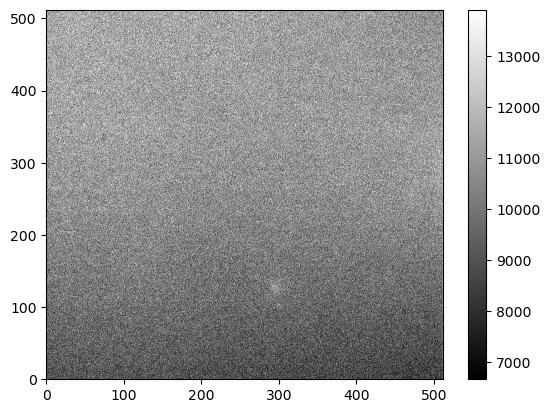

In [58]:
exposure = 0.001
EMGain = 255
arr_sig = np.rot90(single_image(exposure, EMGain),-1)
plt.pcolormesh(arr_sig,cmap="gray")
plt.colorbar()

In [447]:
print(Actual_list)

[195.55714811197888, 175.83710384114582, 84.46485859374984, 46.80463463541661, 49.85881302083299]


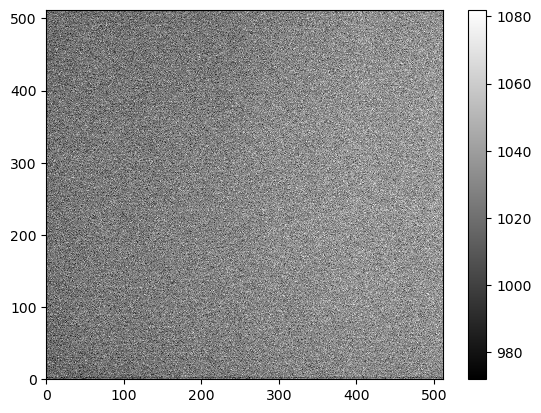

In [489]:
arr_bg = np.rot90(single_image(exposure, EMGain),-1)
plt.pcolormesh(arr_bg,cmap="gray")
plt.colorbar()

In [490]:
EMGain_list.append(EMGain)

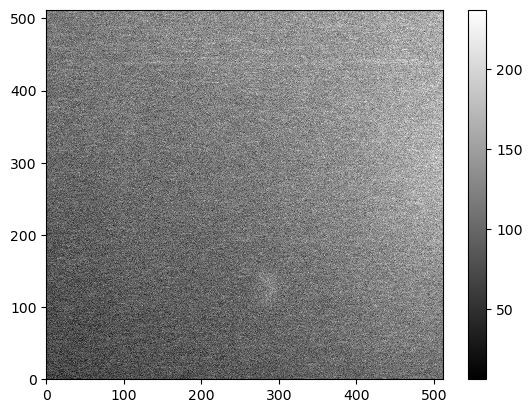

In [491]:
arr_diff = arr_sig-arr_bg
plt.pcolormesh(arr_diff,cmap="gray")
plt.colorbar()

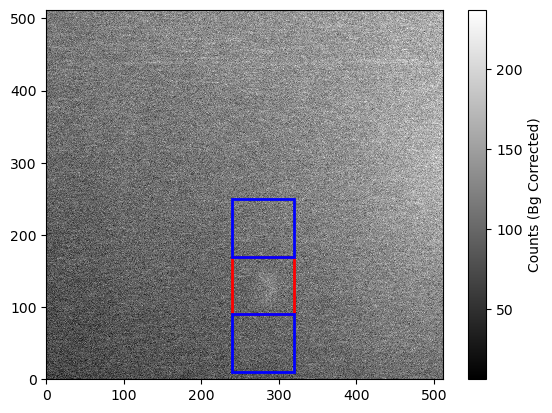

Background (BG): 103.36953125
Corrected counts (Nc): 20816.000000000033
Incident photons (Np): 564705.8823529413
Actual Gain: 1.059772916666668


In [492]:


# Display the data as an image
plt.pcolormesh(arr_diff, cmap='gray')
plt.colorbar(label='Counts (Bg Corrected)')


# Define the regions of interest (ROI and background)
x0, y0 = 240, 90# bottom-left corner of ROI
width, height = 80, 80   # side lengths of the square

# Draw ROI (red square)
rect = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=2, edgecolor='red', facecolor='none'
)
plt.gca().add_patch(rect)

# Draw background regions (blue squares above and below ROI)
rect1 = patches.Rectangle(
    (x0, y0 + height), width, height,
    linewidth=2, edgecolor='blue', facecolor='none'
)
plt.gca().add_patch(rect1)

rect2 = patches.Rectangle(
    (x0, y0 - height), width, height,
    linewidth=2, edgecolor='blue', facecolor='none'
)
plt.gca().add_patch(rect2)

plt.show()

# Calculate background (average of upper and lower regions)
BG1 = np.mean(arr_diff[y0 + height : y0 + 2 * height, x0 : x0 + width])
BG2 = np.mean(arr_diff[y0 - height : y0, x0 : x0 + width])
BG = (BG1 + BG2) / 2
print("Background (BG):", BG)

# Extract the region of interest (ROI)
ROI = arr_diff[y0 : y0 + height, x0 : x0 + width]

# Calculate corrected photon counts in ROI
Nc = np.sum(ROI - BG)
print("Corrected counts (Nc):", Nc)

# Experimental parameters
P = 24e-12    # laser power (W)
t = exposure     # exposure time (s)
h = 6.63e-34  # Planck's constant (J·s)
c = 3e8       # speed of light (m/s)

# Number of incident photons
Np = P * t / (h * (c / 780e-9))
print("Incident photons (Np):", Np)

# Actual gain calculation
Actual_Gain = 23 / 0.8 * Nc / Np
print("Actual Gain:", Actual_Gain)


In [493]:
Actual_list.append(Actual_Gain)

Text(0.5, 1.0, 'calibration curve at -50C')

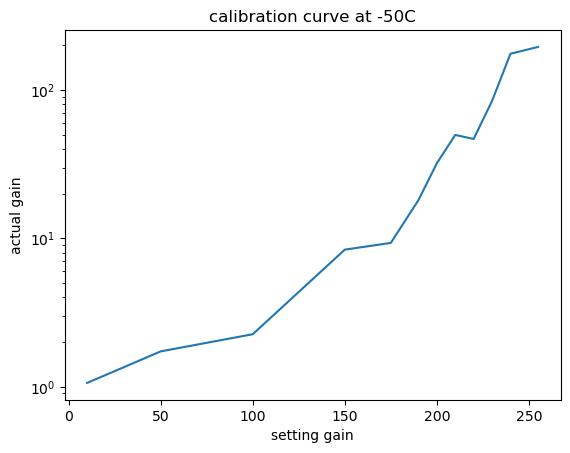

In [497]:
plt.semilogy(EMGain_list,Actual_list)
plt.xlabel("setting gain")
plt.ylabel("actual gain")
plt.title("calibration curve at -50C")

In [263]:
sdk.GetHSSpeed(0,0,0)

(20002, 10.0)

In [265]:
sdk.SetADChannel(0)
sdk.SetOutputAmplifier(0)

20002

In [ ]:
from pyAndorSDK2 import atmcd, atmcd_codes, atmcd_errors

sdk = atmcd()  # Load the atmcd library
codes = atmcd_codes

ret = sdk.Initialize("")  # Initialize camera
print("Function Initialize returned {}".format(ret))



 (ret, iSerialNumber) = sdk.GetCameraSerialNumber()

     ret, iSerialNumber))

 ret = sdk.CoolerON()

ret = sdk.SetAcquisitionMode(codes.Acquisition_Mode.SINGLE_SCAN)
ret = sdk.SetReadMode(codes.Read_Mode.IMAGE)
ret = sdk.SetTriggerMode(codes.Trigger_Mode.INTERNAL)
(ret, xpixels, ypixels) = sdk.GetDetector()
ret = sdk.SetExposureTime(0.01)
ret = sdk.PrepareAcquisition()
ret = sdk.StartAcquisition()
ret = sdk.WaitForAcquisition()
imageSize = xpixels * ypixels
(ret, arr, validfirst, validlast) = sdk.GetImages16(1, 1, imageSize)
ret = sdk.ShutDown()
